<a href="https://colab.research.google.com/github/krishthapa-portfolio/Krish_INFO4670_Fall2026/blob/main/Northgate_Visualization_KrishThapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** Krish Thapa    **Date:**9/26/2026

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [ ]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
#from google.colab import drive
#drive.mount("/content/drive")
#DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [ ]:
# how many rows, which columns, what types?
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

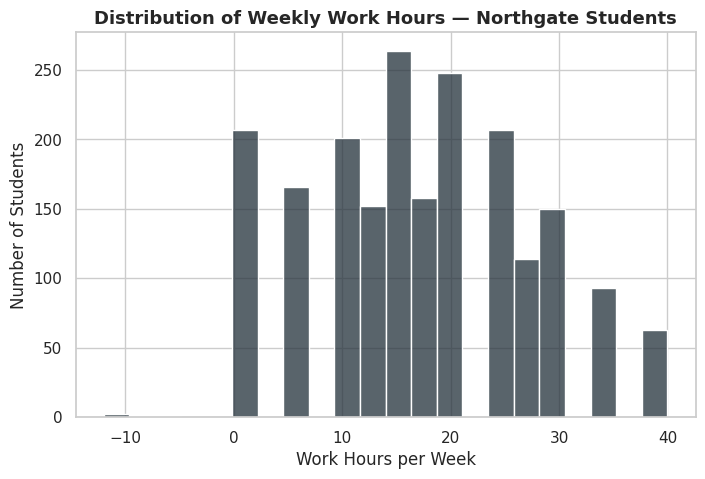

count    2027.000000
mean       17.284164
std        10.401333
min       -12.000000
25%        10.000000
50%        18.000000
75%        25.000000
max        40.000000
Name: work_hours_per_week, dtype: float64


In [ ]:
fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)
ax.set_title("Distribution of Weekly Work Hours — Northgate Students")
ax.set_xlabel("Work Hours per Week")
ax.set_ylabel("Number of Students")
plt.show()

# Get the actual numbers so your STAR story is accurate, not guessed
print(students["work_hours_per_week"].describe())


**STAR story — Q1**

- **Scope —** Work hours per week for all 2027 Northgate students.
- **Track —** How many hours students typically work, how spread out that is, and whether anyone stands apart.
- **Articulate —** The typical student works 18 hours a week, with most students falling between 10 and 25 hours (spread of about 10 hours either way). The shape is roughly even, no strong skew.
- **Respond —** The minimum is negative 12 hours, which is impossible and points to a data entry error rather than a real student. That should show up as an outlier in the boxplot and should be cleaned before trusting any average built on this column.


### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

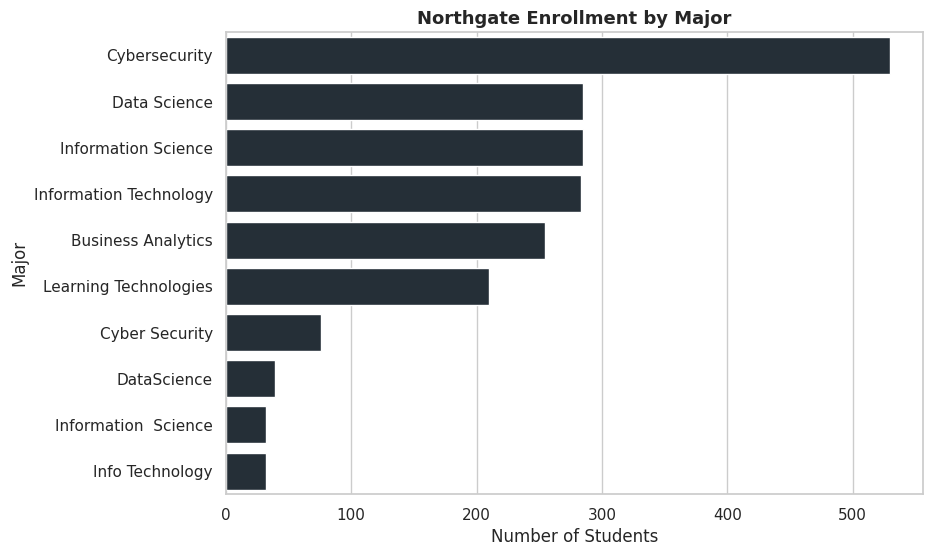

major
Cybersecurity             530
Data Science              285
Information Science       285
Information Technology    283
Business Analytics        255
Learning Technologies     210
Cyber Security             76
DataScience                39
Information  Science       32
Info Technology            32
Name: count, dtype: int64


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
major_counts = students["major"].value_counts().sort_values(ascending=False)
sns.barplot(x=major_counts.values, y=major_counts.index, color=NAVY, ax=ax)
ax.set_title("Northgate Enrollment by Major")
ax.set_xlabel("Number of Students")
ax.set_ylabel("Major")
plt.show()

print(major_counts)


**STAR story — Q2**

- **Scope —** Enrollment counts by `major` for all 2027 students.
- **Track —** Which majors have the most students and which have the fewest.
- **Articulate —** Cybersecurity leads with 530 students. The smallest categories sit at 32 students each.
- **Respond —** Some of these are the same major typed differently: Cybersecurity/Cyber Security, Data Science/DataScience, Information Science/Information  Science , Information Technology/Info Technology. Merged, Cybersecurity is really 606 and Information Technology is 315, which changes the ranking. I'd clean these labels before trusting the counts.

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

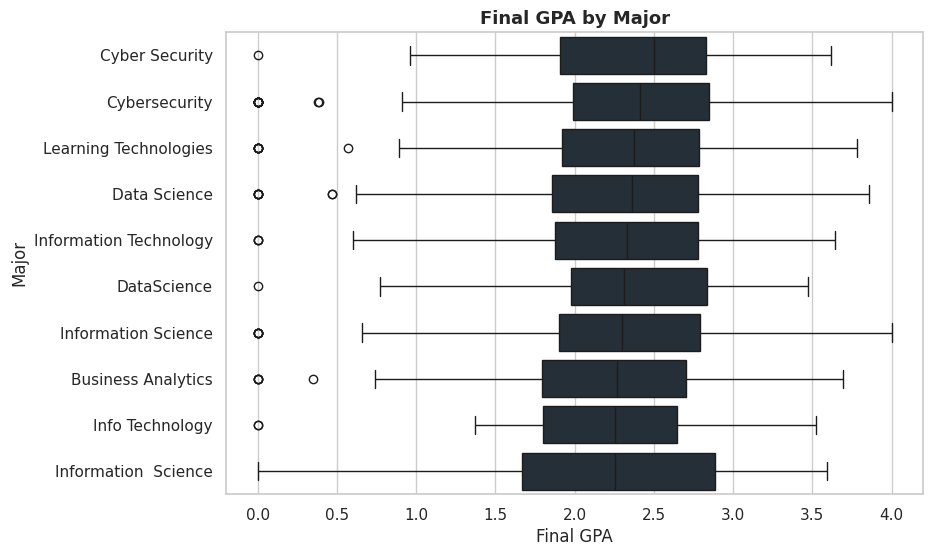

major
Cyber Security            2.500
Cybersecurity             2.410
Learning Technologies     2.375
Data Science              2.360
Information Technology    2.330
DataScience               2.310
Information Science       2.300
Business Analytics        2.270
Info Technology           2.255
Information  Science      2.255
Name: final_gpa, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
order = students.groupby("major")["final_gpa"].median().sort_values(ascending=False).index
sns.boxplot(data=students, x="final_gpa", y="major", order=order, color=NAVY, ax=ax)
ax.set_title("Final GPA by Major")
ax.set_xlabel("Final GPA")
ax.set_ylabel("Major")
plt.show()

print(students.groupby("major")["final_gpa"].median().sort_values(ascending=False))


**STAR story — Q3**

- **Scope —** `final_gpa` for every student, split by `major`.
- **Track —** Whether GPA typically differs across majors.
- **Articulate —** Median GPA is close across the board, from 2.255 up to 2.500. Cyber Security sits highest, the split versions of Information Science and Info Technology sit lowest.
- **Respond —** Same duplicate problem as Q2: Cyber Security/Cybersecurity and Data Science/DataScience are split into separate rows again. I can't just average their medians together to fix this, so I'd re-run the boxplot after cleaning the major labels first. I'd also check the boxplot itself for outlier dots near 0.0, since a spread this tight can still hide a few students in real trouble.


### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

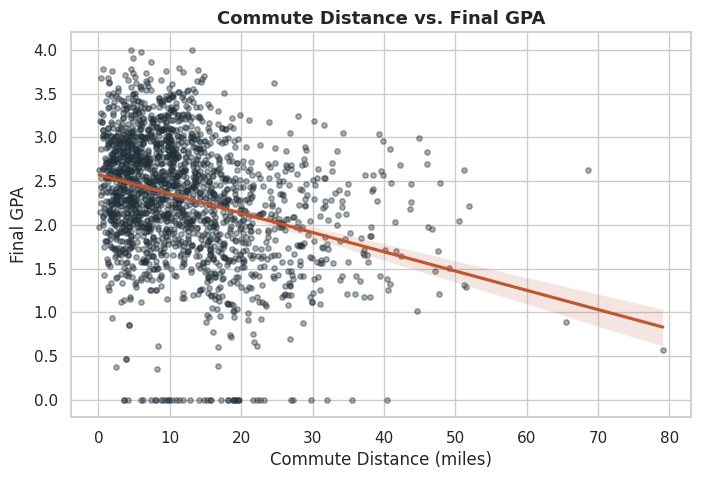

               commute_miles  final_gpa
commute_miles       1.000000  -0.295108
final_gpa          -0.295108   1.000000


In [ ]:
fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa",
            scatter_kws={"color": NAVY, "alpha": 0.4, "s": 15},
            line_kws={"color": RUST}, ax=ax)
ax.set_title("Commute Distance vs. Final GPA")
ax.set_xlabel("Commute Distance (miles)")
ax.set_ylabel("Final GPA")
plt.show()

print(students[["commute_miles", "final_gpa"]].corr())


**STAR story — Q4**

- **Scope —** `commute_miles` against `final_gpa` for all students.
- **Track —** Whether living farther from campus lines up with a lower GPA.
- **Articulate —** Correlation is -0.295. Weak, but real: longer commutes trend with slightly lower GPA.
- **Respond —** Association, not causation. The commute itself probably isn't the cause, it's more likely standing in for something else like less time to study. Worth checking students with the longest commutes to see if they cluster at a specific GPA range before drawing any conclusion.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

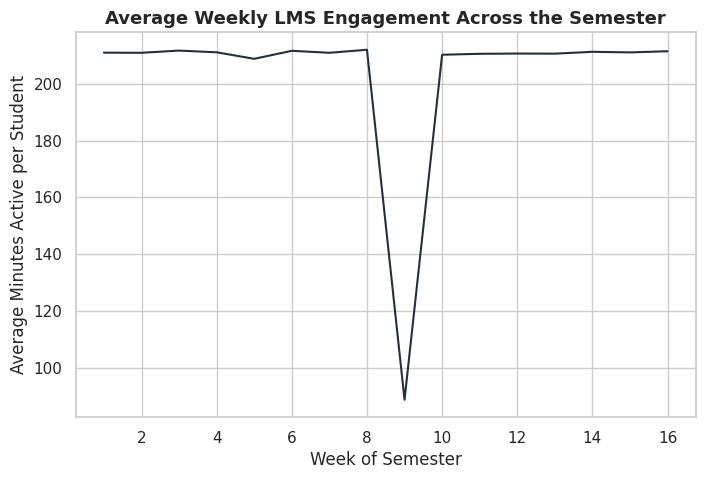

    week  minutes_active
0      1        210.9805
1      2        210.9365
2      3        211.7105
3      4        211.1095
4      5        208.8125
5      6        211.6380
6      7        210.9370
7      8        212.0085
8      9         88.6370
9     10        210.2460
10    11        210.5785
11    12        210.6665
12    13        210.6300
13    14        211.2850
14    15        211.0785
15    16        211.4795


In [ ]:
# weekly has one row per student per week, with a minutes-active column.
# check weekly.columns / weekly.head() first if these names don't match.
fig, ax = plt.subplots()
weekly_avg = weekly.groupby("week")["minutes_active"].mean().reset_index()
sns.lineplot(data=weekly_avg, x="week", y="minutes_active", color=NAVY, ax=ax)
ax.set_title("Average Weekly LMS Engagement Across the Semester")
ax.set_xlabel("Week of Semester")
ax.set_ylabel("Average Minutes Active per Student")
plt.show()

print(weekly_avg)


**STAR story — Q5**

- **Scope —** Average `minutes_active` per week, across all students, for all 16 weeks.
- **Track —** Whether engagement holds steady, climbs, or drops off across the semester.
- **Articulate —** Engagement is flat almost the whole way, holding around 210 to 212 minutes every week.
- **Respond —** Week 9 crashes to 88.6, way below every other week, then bounces right back to normal in week 10. That's too sharp and too brief to be a real semester-wide drop, more likely a data recording issue for that week (maybe an LMS outage or logging gap) than an actual dip in student engagement. Worth checking the raw logs for week 9 before reporting it as real.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** Does the number of advisor meetings a student has relate to whether they drop out?



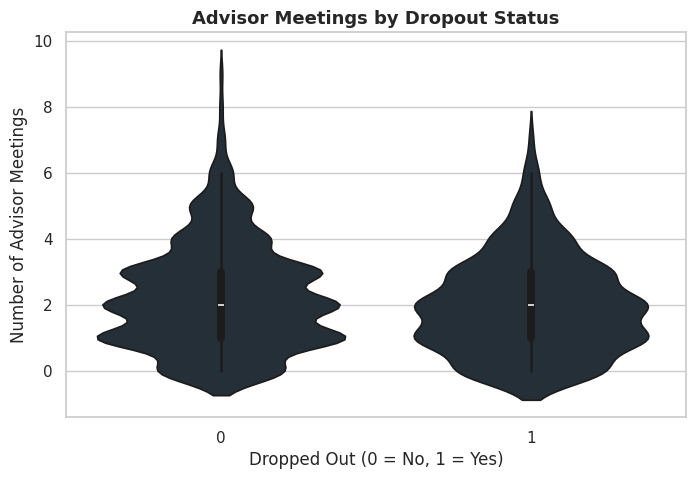

              count      mean      std  min  25%  50%  75%  max
dropped_out                                                    
0            1600.0  2.250000  1.61992  0.0  1.0  2.0  3.0  9.0
1             427.0  1.981265  1.47900  0.0  1.0  2.0  3.0  7.0


In [ ]:
fig, ax = plt.subplots()
sns.violinplot(data=students, x="dropped_out", y="advisor_meetings", color=NAVY, ax=ax)
ax.set_title("Advisor Meetings by Dropout Status")
ax.set_xlabel("Dropped Out (0 = No, 1 = Yes)")
ax.set_ylabel("Number of Advisor Meetings")
plt.show()

print(students.groupby("dropped_out")["advisor_meetings"].describe())


**STAR story — Part B**

- **Scope —** `advisor_meetings` for all students, split by whether they dropped out.
- **Track —** Whether students who dropped out met with an advisor less than students who stayed.
- **Articulate —** Median meetings are the same for both groups, 2. The averages are close too, 2.25 for students who stayed versus 1.98 for those who dropped out.
- **Respond —** Honestly the gap here is too small to call this a real warning sign on its own. I picked advisor meetings expecting a bigger split, but it doesn't separate the two groups much. If I were building an early-warning system I'd look at something with more separation, like GPA or study hours, instead of leaning on this one.


# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.